In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from scipy.special import gammaln
from lifelines import KaplanMeierFitter

In [2]:
DATA_DIR = Path("../data/CMAPSSData")
IMG_DIR = Path("../images")
IMG_DIR.mkdir(exist_ok=True)

In [3]:
COLS = ["unit", "cycle"] + [f"op_{i}" for i in range(1, 4)] + [f"s_{i}" for i in range(1, 22)]
train = pd.read_csv(DATA_DIR / "train_FD001.txt", sep=r"\s+", header=None, names=COLS, engine="python")
test = pd.read_csv(DATA_DIR / "test_FD001.txt", sep=r"\s+", header=None, names=COLS, engine="python")
rul_test = pd.read_csv(DATA_DIR / "RUL_FD001.txt", header=None, names=["RUL"]).squeeze("columns")
life_train = train.groupby("unit").cycle.max().values.astype(float)
life_test = test.groupby("unit").cycle.max().values + rul_test.values
life_all = np.concatenate([life_train, life_test.astype(float)])

In [4]:
# ---------------- 1. Weibull MLE (floc=0, 2-param) ----------------
beta, _, eta = stats.weibull_min.fit(life_all, floc=0)
print("=" * 72)
print("WEIBULL MLE FIT  (pooled n=200)")
print("=" * 72)
print(f"  shape  β  = {beta:.3f}   (>1  →  increasing hazard, wear-out)")
print(f"  scale  η  = {eta:.2f}   cycles   (characteristic life; F(η)≈0.632)")

WEIBULL MLE FIT  (pooled n=200)
  shape  β  = 4.547   (>1  →  increasing hazard, wear-out)
  scale  η  = 224.78   cycles   (characteristic life; F(η)≈0.632)


In [5]:
# Bootstrap 95% CI on β, η
rng = np.random.default_rng(42)
B = 2000
boot = np.empty((B, 2))
for i in range(B):
    sample = rng.choice(life_all, size=len(life_all), replace=True)
    b, _, s = stats.weibull_min.fit(sample, floc=0)
    boot[i] = [b, s]
ci_beta = np.percentile(boot[:, 0], [2.5, 97.5])
ci_eta = np.percentile(boot[:, 1], [2.5, 97.5])
print(f"  β 95% CI  [{ci_beta[0]:.3f}, {ci_beta[1]:.3f}]  (bootstrap, B={B})")
print(f"  η 95% CI  [{ci_eta[0]:.2f}, {ci_eta[1]:.2f}]")

  β 95% CI  [4.165, 5.119]  (bootstrap, B=2000)
  η 95% CI  [217.54, 232.41]


In [6]:
mttf_weibull = eta * np.exp(gammaln(1 + 1 / beta))
B10_weibull = eta * (-np.log(0.9)) ** (1 / beta)
B50_weibull = eta * (-np.log(0.5)) ** (1 / beta)
print(f"\n  Weibull MTTF    = η·Γ(1+1/β) = {mttf_weibull:.1f}   (empirical: {life_all.mean():.1f})")
print(f"  Weibull B10     = {B10_weibull:.1f}            (empirical: {np.percentile(life_all,10):.1f})")
print(f"  Weibull B50     = {B50_weibull:.1f}            (empirical: {np.percentile(life_all,50):.1f})")


  Weibull MTTF    = η·Γ(1+1/β) = 205.3   (empirical: 206.4)
  Weibull B10     = 137.0            (empirical: 154.0)
  Weibull B50     = 207.4            (empirical: 199.0)


In [7]:
# ---------------- 2. Goodness of fit ----------------
ks_stat, ks_p = stats.kstest(life_all, "weibull_min", args=(beta, 0, eta))
print("\n" + "=" * 72)
print("GOODNESS OF FIT")
print("=" * 72)
print(f"  KS test           D = {ks_stat:.4f}   p = {ks_p:.3f}   "
      f"{'(fit accepted)' if ks_p > 0.05 else '(fit rejected)'}")


GOODNESS OF FIT
  KS test           D = 0.1390   p = 0.001   (fit rejected)


In [8]:
# Compare Weibull vs Lognormal vs Exponential via AIC
def aic(logL, k):
    return 2 * k - 2 * logL

In [9]:
# Weibull logL
logL_w = np.sum(stats.weibull_min.logpdf(life_all, beta, 0, eta))
# Lognormal
s_ln, loc_ln, scale_ln = stats.lognorm.fit(life_all, floc=0)
logL_ln = np.sum(stats.lognorm.logpdf(life_all, s_ln, loc_ln, scale_ln))
# Exponential (1 param)
loc_e, scale_e = stats.expon.fit(life_all, floc=0)
logL_e = np.sum(stats.expon.logpdf(life_all, loc_e, scale_e))
 
comp = pd.DataFrame([
    {"model": "Weibull",     "k": 2, "logL": logL_w,  "AIC": aic(logL_w,  2)},
    {"model": "Lognormal",   "k": 2, "logL": logL_ln, "AIC": aic(logL_ln, 2)},
    {"model": "Exponential", "k": 1, "logL": logL_e,  "AIC": aic(logL_e,  1)},
]).sort_values("AIC").reset_index(drop=True)
comp["ΔAIC"] = comp.AIC - comp.AIC.min()
print("\nModel comparison (lower AIC = better):")
print(comp.round(2).to_string(index=False))


Model comparison (lower AIC = better):
      model  k     logL     AIC   ΔAIC
  Lognormal  2 -1031.10 2066.21   0.00
    Weibull  2 -1056.40 2116.79  50.59
Exponential  1 -1265.96 2533.92 467.71


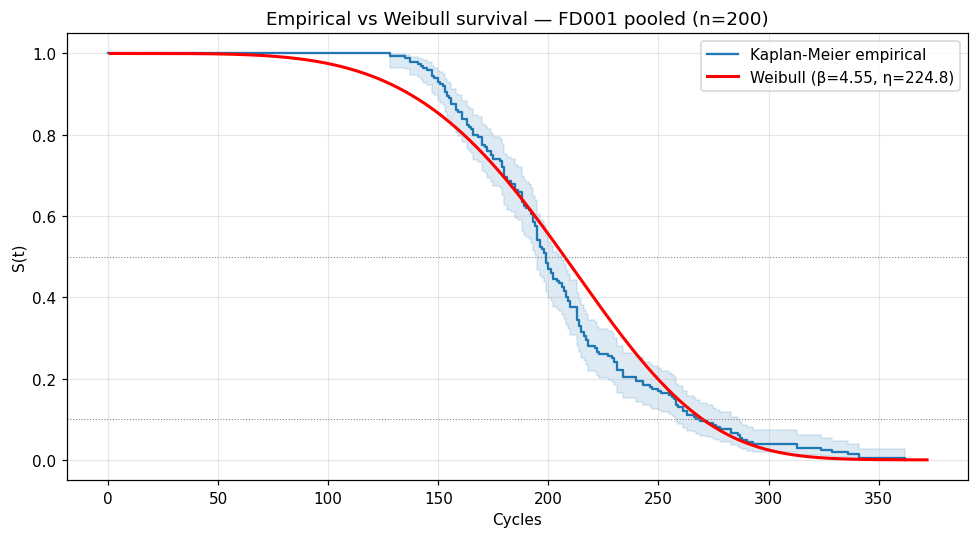

In [10]:
# ---------------- 3. Plots ----------------
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
 
# 3a. Empirical survival + Weibull survival overlay
kmf = KaplanMeierFitter(label="Kaplan-Meier empirical")
kmf.fit(life_all, event_observed=np.ones_like(life_all))
t_grid = np.linspace(1, life_all.max() + 10, 500)
S_weibull = stats.weibull_min.sf(t_grid, beta, 0, eta)
 
fig, ax = plt.subplots(figsize=(9, 5))
kmf.plot_survival_function(ax=ax, color="tab:blue", ci_alpha=0.15)
ax.plot(t_grid, S_weibull, "r-", lw=2, label=f"Weibull (β={beta:.2f}, η={eta:.1f})")
ax.axhline(0.5, color="gray", ls=":", lw=0.7)
ax.axhline(0.1, color="gray", ls=":", lw=0.7)
ax.set_xlabel("Cycles")
ax.set_ylabel("S(t)")
ax.set_title("Empirical vs Weibull survival — FD001 pooled (n=200)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(IMG_DIR / "08_weibull_survival.png", bbox_inches="tight")
plt.show()
plt.close()

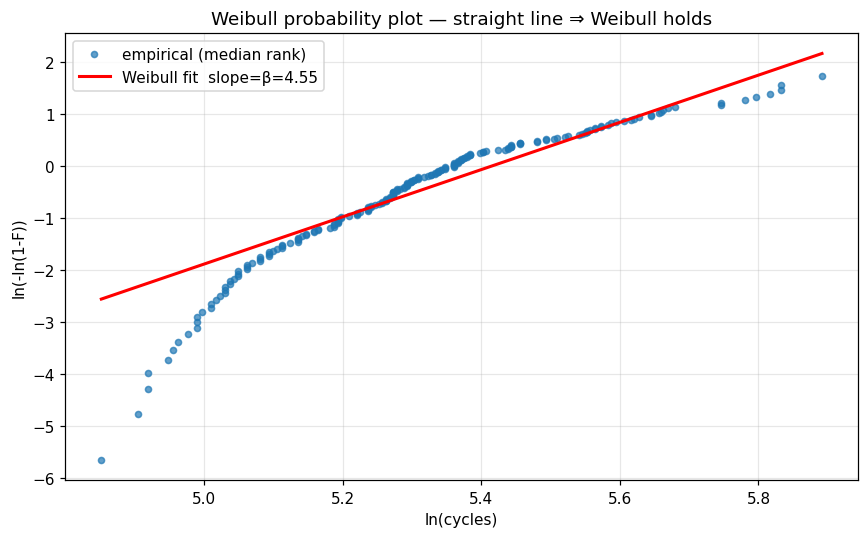

In [11]:
# 3b. Weibull probability plot (linearized: ln(t) vs ln(-ln(1-F)))
sorted_t = np.sort(life_all)
n = len(sorted_t)
F_med = (np.arange(1, n + 1) - 0.3) / (n + 0.4)   # median rank
x = np.log(sorted_t)
y = np.log(-np.log(1 - F_med))
 
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, y, "o", ms=4, color="tab:blue", alpha=0.7, label="empirical (median rank)")
x_line = np.linspace(x.min(), x.max(), 50)
y_line = beta * (x_line - np.log(eta))
ax.plot(x_line, y_line, "r-", lw=2, label=f"Weibull fit  slope=β={beta:.2f}")
ax.set_xlabel("ln(cycles)")
ax.set_ylabel("ln(-ln(1-F))")
ax.set_title("Weibull probability plot — straight line ⇒ Weibull holds")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(IMG_DIR / "09_weibull_probplot.png", bbox_inches="tight")
plt.show()
plt.close()

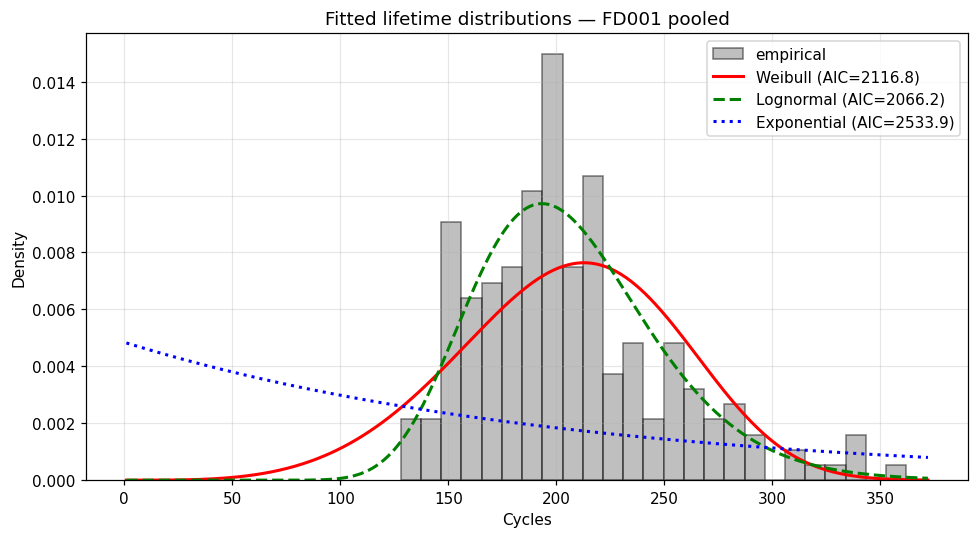

In [12]:
# 3c. PDF histogram with fitted densities
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(life_all, bins=25, density=True, alpha=0.5, color="gray",
        edgecolor="black", label="empirical")
ax.plot(t_grid, stats.weibull_min.pdf(t_grid, beta, 0, eta),
        "r-", lw=2, label=f"Weibull (AIC={aic(logL_w,2):.1f})")
ax.plot(t_grid, stats.lognorm.pdf(t_grid, s_ln, loc_ln, scale_ln),
        "g--", lw=2, label=f"Lognormal (AIC={aic(logL_ln,2):.1f})")
ax.plot(t_grid, stats.expon.pdf(t_grid, loc_e, scale_e),
        "b:", lw=2, label=f"Exponential (AIC={aic(logL_e,1):.1f})")
ax.set_xlabel("Cycles")
ax.set_ylabel("Density")
ax.set_title("Fitted lifetime distributions — FD001 pooled")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(IMG_DIR / "10_density_comparison.png", bbox_inches="tight")
plt.show()
plt.close()


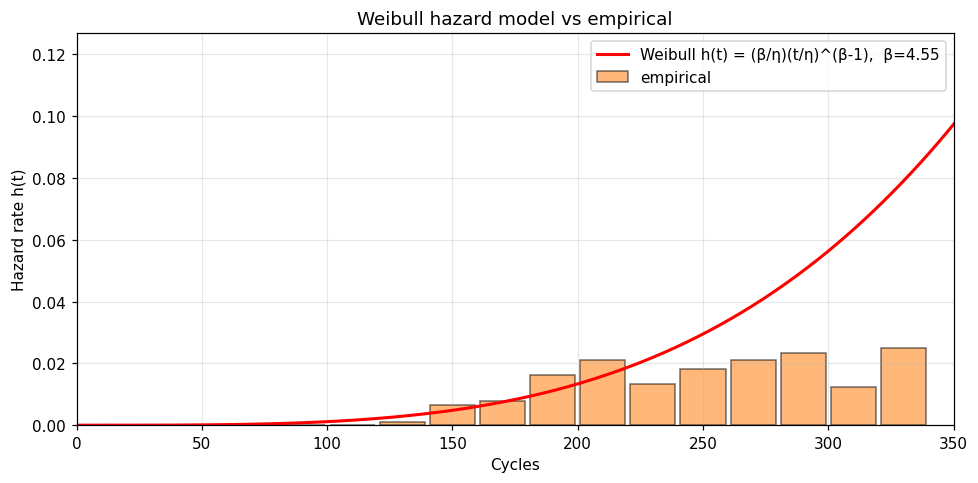

In [13]:
# 3d. Weibull hazard vs empirical (from step 2)
h_weibull = (beta / eta) * (t_grid / eta) ** (beta - 1)
bin_width = 20
edges = np.arange(0, int(life_all.max()) + bin_width + 1, bin_width)
centers = (edges[:-1] + edges[1:]) / 2
n_at_risk = np.array([(life_all >= e).sum() for e in edges[:-1]])
n_events = np.histogram(life_all, bins=edges)[0]
with np.errstate(divide="ignore", invalid="ignore"):
    h_emp = np.where(n_at_risk > 0, n_events / (n_at_risk * bin_width), np.nan)
mask = n_at_risk >= 5
 
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(centers[mask], h_emp[mask], width=bin_width * 0.9,
       alpha=0.55, color="tab:orange", edgecolor="black", label="empirical")
ax.plot(t_grid, h_weibull, "r-", lw=2, label=f"Weibull h(t) = (β/η)(t/η)^(β-1),  β={beta:.2f}")
ax.set_xlabel("Cycles")
ax.set_ylabel("Hazard rate h(t)")
ax.set_title("Weibull hazard model vs empirical")
ax.legend()
ax.grid(alpha=0.3)
ax.set_xlim(0, centers[mask].max() + bin_width)
plt.tight_layout()
plt.savefig(IMG_DIR / "11_weibull_hazard.png", bbox_inches="tight")
plt.show()
plt.close()

In [14]:
comp.to_csv("weibull_model_comparison.csv", index=False)